# **Assignment 2: Secure ML Pipeline**

**Course:** Introduction to Data Security Pr.  
**Total Points:**  20  
**Estimated Time:** 90 min

---

**Submission Instructions**

1. **Make sure your notebook is complete** (Run all cells before submitting).

2. **Save your final notebook** (Use the filename format: **`Assignment_2_FirstName_LastName_NeptunCode.ipynb`**).

3. **Upload your notebook to Microsoft Teams**
   - Go to the **Teams channel**.
   - Open the folder named **`Assignment_2`**.
   - Upload your `.ipynb` file into **`Submissions`** folder.

4. **Verify your upload**
   - Make sure the file appears in the folder.
   - Confirm that the correct version was uploaded.

**Assignment Goals:**

1. **Design** a multi-threat secure ML system
2. **Implement** layered defenses: data pipeline, adversarial training, DP-SGD, input validation
3. **Evaluate** 6 attack types: evasion (FGSM, PGD), poisoning (label-flip, backdoor), trojans, inversion, MIA, sponge
4. **Defend** with detection mechanisms: trojan activation clustering, synthetic data, rate limiting
5. **Operationalize** security: monitoring, logging, incident response, deployment checklist

You are the ML security lead for a healthcare imaging startup. The company deploys a
cloud-hosted classifier for medical triage. Your system must withstand:

- **Evasion attacks:** Adversarial perturbations to fool predictions
- **Data poisoning:** Malicious training samples injected into the pipeline
- **Model trojans:** Backdoors injected into model weights via supply chain attacks
- **Membership inference:** Adversaries trying to detect patient data inclusion
- **Model inversion:** Privacy attacks to reconstruct training data from model outputs
- **Sponge attacks:** Resource exhaustion via crafted inputs

Your job: build a secure pipeline, quantify its performance, and operationalize defenses.

## Threat Model <a id="threat-model"></a>

| Layer | Threat | Goal | Attacker | Defense |
|-------|--------|------|----------|---------|
| **Data** | Label-flip poisoning | Degrade accuracy | Insider | Outlier detection |
| **Data** | Backdoor samples | Plant trojan trigger | Supply chain | Data sanitization |
| **Training** | Membership inference | Privacy leakage | Black-box | DP-SGD |
| **Model** | Weight trojans | Hidden functionality | Post-hoc compromise | Activation clustering |
| **Inference** | Evasion (FGSM/PGD) | Misclassification | White-box | Adversarial training |
| **Inference** | Model inversion | Reconstruct training data | Black-box | Differential privacy |
| **Inference** | Sponge attacks | DoS/resource exhaustion | Black-box | Input validation + rate limiting |
| **Ops** | Model theft | IP exposure | Reconnaissance | Logging + anomaly detection |

## Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as transforms
from torchvision.datasets import MNIST

import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from dataclasses import dataclass
from sklearn.metrics import roc_auc_score

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# we use MNIST handwritten digits for implementation simplicity
train_dataset = MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = MNIST(root='./data', train=False, download=True, transform=transform)

# Use subset for faster execution
train_indices = np.random.choice(len(train_dataset), 8000, replace=False)
test_indices = np.random.choice(len(test_dataset), 2000, replace=False)

train_data = Subset(train_dataset, train_indices)
test_data = Subset(test_dataset, test_indices)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

print(f"Train: {len(train_data)}, Test: {len(test_data)}")

Device: cpu
Train: 8000, Test: 2000


In [2]:
# Simple CNN for MNIST classification
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
    
    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += target.size(0)
    return 100.0 * correct / total

## Baseline Model

Training a baseline model (without defenses) on clean data. This will be your reference before adding defenses.

In [4]:
def train_standard(model, loader, epochs=1):
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    criterion = nn.CrossEntropyLoss()
    for epoch in range(epochs):
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
        print(f'Epoch {epoch+1}/{epochs}')

baseline_model = CNN().to(device)
baseline_loader = DataLoader(train_data, batch_size=64, shuffle=True)
train_standard(baseline_model, baseline_loader, epochs=1)

baseline_train_acc = evaluate(baseline_model, train_loader)
baseline_test_acc = evaluate(baseline_model, test_loader)
print(f'\nBaseline Model Accuracy: Train={baseline_train_acc:.2f}%, Test={baseline_test_acc:.2f}%')

Epoch 1/1

Baseline Model Accuracy: Train=93.29%, Test=93.65%


## Secure Data Pipeline: Poisoning + Detection

- Simulate a label‑flip poisoning attack (use a small poison rate, e.g. 10%).
- Train a model on the poisoned training split and compare test accuracy with the baseline model.
- Compute class label distributions before and after poisoning and decide on a simple sanitization step (e.g., downsample overrepresented target label).

Expected output: poison count, label distribution summary, baseline vs poisoned test accuracy, and a one‑line sanitization decision.

In [6]:
def poison_labels(dataset, poison_rate=0.1, target_label=0):
    """Flip labels for a fraction of samples (label-flipping attack)."""
    indices = np.random.choice(len(dataset), int(poison_rate * len(dataset)), replace=False)
    poisoned = []
    for i in range(len(dataset)):
        x, y = dataset[i]
        if i in indices:
            poisoned.append((x, target_label))
        else:
            poisoned.append((x, y))
    return poisoned, indices

# Parameters
poison_rate = 0.10
target_label = 0

# 1) Create poisoned dataset
poisoned_data, poisoned_indices = poison_labels(train_data, poison_rate=poison_rate, target_label=target_label)
print(f'Poisoned samples (label flips): {len(poisoned_indices)} / {len(poisoned_data)}')

# 2) Show label distribution before/after poisoning
orig_labels = [y for _, y in train_data]
poisoned_labels = [y for _, y in poisoned_data]
orig_dist = Counter(orig_labels)
poisoned_dist = Counter(poisoned_labels)
print('\nOriginal label counts:')
print(dict(orig_dist))
print('\nPoisoned label counts:')
print(dict(poisoned_dist))

# 3) Train a quick poisoned-model baseline and compare to baseline_model
poisoned_loader = DataLoader(poisoned_data, batch_size=64, shuffle=True)
poisoned_model = CNN().to(device)
train_standard(poisoned_model, poisoned_loader, epochs=1)
poisoned_test_acc = evaluate(poisoned_model, test_loader)
print(f'\nBaseline Test Accuracy: {baseline_test_acc:.2f}%')
print(f'Poisoned-model Test Accuracy: {poisoned_test_acc:.2f}%')
print(f'Accuracy drop (poisoned - baseline): {poisoned_test_acc - baseline_test_acc:+.2f}pp')

# 4) Simple sanitization heuristic: if target_label proportion increases noticeably, downsample to expected proportion
n = len(poisoned_data)
expected_prop = 1.0 / 10.0  # MNIST ~10 classes
prop_target = poisoned_dist.get(target_label, 0) / n
print(f'\nTarget label proportion after poisoning: {prop_target:.3f} (expected ~{expected_prop:.3f})')

if prop_target > expected_prop + 0.05:
    # downsample target_label to expected proportion
    target_indices = [i for i, (_, y) in enumerate(poisoned_data) if y == target_label]
    keep_target = int(expected_prop * n)
    # deterministic subset: keep first `keep_target` occurrences
    keep_set = set(target_indices[:max(0, keep_target)])
    sanitized_data = [s for i, s in enumerate(poisoned_data) if not (i in target_indices and i not in keep_set)]
    decision = f'DOWN_SAMPLE_TARGET — reduced target label to approx {expected_prop:.2f}'
else:
    sanitized_data = poisoned_data
    decision = 'KEEP_ALL — no large target-label imbalance detected'

print('\nSanitization decision:', decision)
print(f'Sanitized dataset size: {len(sanitized_data)}')

Poisoned samples (label flips): 800 / 8000

Original label counts:
{7: 852, 3: 793, 8: 775, 9: 818, 5: 739, 4: 778, 2: 786, 6: 778, 1: 884, 0: 797}

Poisoned label counts:
{7: 776, 3: 718, 8: 706, 9: 735, 5: 650, 4: 695, 2: 696, 6: 716, 1: 790, 0: 1518}
Epoch 1/1

Baseline Test Accuracy: 93.65%
Poisoned-model Test Accuracy: 92.25%
Accuracy drop (poisoned - baseline): -1.40pp

Target label proportion after poisoning: 0.190 (expected ~0.100)

Sanitization decision: DOWN_SAMPLE_TARGET — reduced target label to approx 0.10
Sanitized dataset size: 7282


## Robust Training: Adversarial + DP-SGD

- Implement robust training with FGSM-based adversarial examples.
- Add DP-SGD style clipping and noise in the training step.
- Compare secure model accuracy against baseline.

Expected output: secure train/test accuracy with clear defense configuration.

In [8]:
@dataclass
class DefenseConfig:
    epsilon_adv: float = 0.1
    clip_norm: float = 1.0
    noise_multiplier: float = 1.0

def fgsm_attack(model, data, target, epsilon=0.1):
    data.requires_grad = True
    output = model(data)
    loss = nn.CrossEntropyLoss()(output, target)
    model.zero_grad()
    loss.backward()
    data_grad = data.grad.detach()
    perturbed = data + epsilon * data_grad.sign()
    return torch.clamp(perturbed, -3, 3).detach()

def dp_sgd_step(model, data, target, config: DefenseConfig):
    model.train()
    criterion = nn.CrossEntropyLoss(reduction='none')
    data, target = data.to(device), target.to(device)

    # Per-sample gradients
    per_sample_grads = []
    for i in range(data.size(0)):
        model.zero_grad()
        output = model(data[i:i+1])
        loss = criterion(output, target[i:i+1]).mean()
        loss.backward()
        grads = [p.grad.detach().clone() for p in model.parameters()]
        per_sample_grads.append(grads)

    # Clip and aggregate
    agg_grads = []
    for param_i in range(len(per_sample_grads[0])):
        stacked = torch.stack([g[param_i] for g in per_sample_grads], dim=0)
        # Clip
        norms = torch.norm(stacked.view(stacked.size(0), -1), dim=1)
        factors = torch.clamp(config.clip_norm / (norms + 1e-6), max=1.0)
        stacked = stacked * factors.view(-1, *([1] * (stacked.dim()-1)))
        agg = stacked.mean(dim=0)
        # Noise
        noise = torch.randn_like(agg) * (config.noise_multiplier * config.clip_norm / data.size(0))
        agg_grads.append(agg + noise)

    for param, grad in zip(model.parameters(), agg_grads):
        param.grad = grad

def train_secure(model, loader, config: DefenseConfig, epochs=3):
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    for epoch in range(epochs):
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            adv = fgsm_attack(model, data, target, epsilon=config.epsilon_adv)
            optimizer.zero_grad()
            dp_sgd_step(model, adv, target, config)
            optimizer.step()
        print(f'Epoch {epoch+1}/{epochs}')

secure_model = CNN().to(device)
secure_loader = DataLoader(sanitized_data, batch_size=64, shuffle=True)
config = DefenseConfig()
train_secure(secure_model, secure_loader, config, epochs=1)

secure_train_acc = evaluate(secure_model, train_loader)
secure_test_acc = evaluate(secure_model, test_loader)
print(f'\nSecure Model Accuracy: Train={secure_train_acc:.2f}%, Test={secure_test_acc:.2f}%')

Epoch 1/1

Secure Model Accuracy: Train=78.22%, Test=77.90%


## Secure Inference: Input Validation + Rate Limiting

- Define simple input validation constraints for inference safety.
- Implement a basic rate limiter and simulate burst requests.
- Report how many requests are allowed under the configured burst.

Expected output: a single burst-control statistic (allowed vs attempted).

In [9]:
@dataclass
class InputPolicy:
    max_abs_value: float = 3.0
    max_variance: float = 2.0

def validate_input(x: torch.Tensor, policy: InputPolicy) -> bool:
    if x.abs().max().item() > policy.max_abs_value:
        return False
    if x.var().item() > policy.max_variance:
        return False
    return True

@dataclass
class RateLimiter:
    max_qps: int = 100
    burst: int = 10
    tokens: int = 10

    def allow(self):
        if self.tokens > 0:
            self.tokens -= 1
            return True
        return False

policy = InputPolicy()
limiter = RateLimiter()

# Simulate 20 requests
allowed = 0
for _ in range(20):
    if limiter.allow():
        allowed += 1

print(f'Requests allowed (burst=10): {allowed}/20')

Requests allowed (burst=10): 10/20


## Model Inversion Attack

- Perform gradient-based model inversion for multiple classes.
- Visualize reconstructed samples and inspect confidence scores.
- Discuss what this implies for confidentiality risk.

Expected output: class-wise inversion confidence and reconstruction plots.

Inverted class 0: confidence=1.000
Inverted class 1: confidence=1.000
Inverted class 2: confidence=1.000


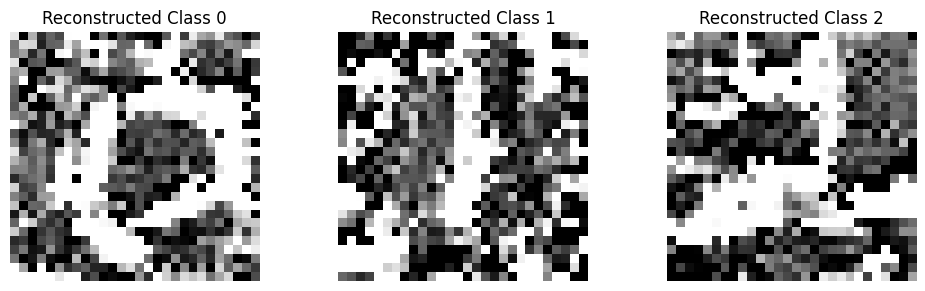

In [10]:
# Gradient-based model inversion: reconstruct representative input per class
def model_inversion_attack(model, target_class, iterations=100, learning_rate=0.1):
    """Reconstruct a representative input for target class via gradient ascent."""
    model.eval()
    x = torch.randn(1, 1, 28, 28, device=device, requires_grad=True)
    optimizer = optim.Adam([x], lr=learning_rate)
    
    for _ in range(iterations):
        optimizer.zero_grad()
        output = model(x)
        
        # Maximize logit for target class
        loss = -output[0, target_class]
        loss.backward()
        optimizer.step()
        
        # Clamp to valid range
        with torch.no_grad():
            x.clamp_(-3, 3)
    
    return x.detach()

# Perform inversion attack on baseline model
inverted_samples = {}
for target_class in range(3):  # Reconstruct for 3 classes
    inverted_x = model_inversion_attack(baseline_model, target_class, iterations=50)
    inverted_samples[target_class] = inverted_x
    out = baseline_model(inverted_x)
    pred_conf = torch.softmax(out, dim=1)[0, target_class].item()
    print(f'Inverted class {target_class}: confidence={pred_conf:.3f}')

# Visualize one inverted sample
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for i in range(3):
    axes[i].imshow(inverted_samples[i].squeeze().cpu().numpy(), cmap='gray')
    axes[i].set_title(f'Reconstructed Class {i}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

## Synthetic Data Generation

- Train a lightweight VAE and generate synthetic MNIST-like samples.
- Visualize the generated images and comment on quality/diversity.
- Relate synthetic data to privacy/utility trade-offs.

Expected output: training logs and a grid of synthetic samples.

VAE Epoch 1/2
VAE Epoch 2/2

Generated 10 synthetic samples


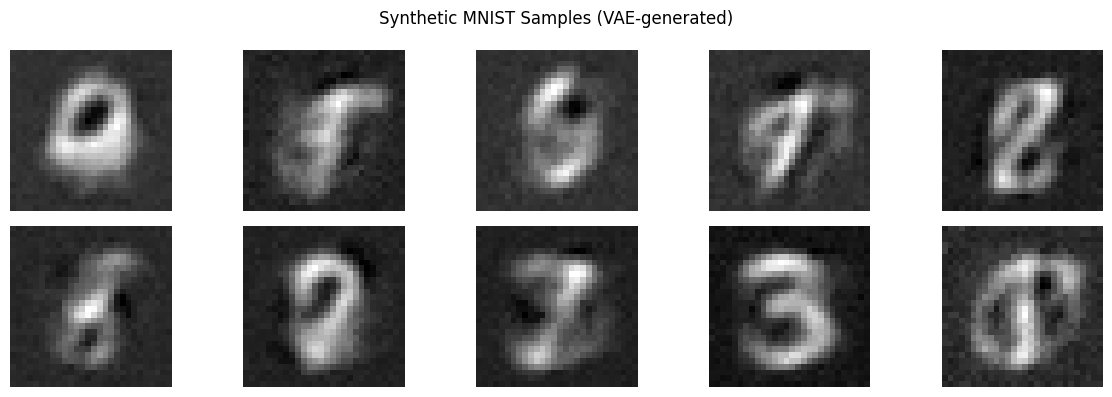

In [11]:
# Simple VAE for synthetic data generation
class VAE(nn.Module):
    def __init__(self, latent_dim=10):
        super().__init__()
        self.latent_dim = latent_dim
        # Encoder: 28x28 → latent
        self.enc1 = nn.Linear(784, 256)
        self.enc_mu = nn.Linear(256, latent_dim)
        self.enc_logvar = nn.Linear(256, latent_dim)
        # Decoder: latent → 28x28
        self.dec1 = nn.Linear(latent_dim, 256)
        self.dec_out = nn.Linear(256, 784)
    
    def encode(self, x):
        h = torch.relu(self.enc1(x.view(-1, 784)))
        mu = self.enc_mu(h)
        logvar = self.enc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        h = torch.relu(self.dec1(z))
        return self.dec_out(h)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

def vae_loss(recon_x, x, mu, logvar):
    """VAE loss: reconstruction + KL divergence."""
    MSE = nn.MSELoss(reduction='sum')(recon_x, x.view(-1, 784))
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return MSE + KLD

# Train VAE for 2 epochs on small subset
vae = VAE(latent_dim=10).to(device)
vae_optimizer = optim.Adam(vae.parameters(), lr=1e-3)
small_loader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=1)

for epoch in range(2):
    for data, _ in small_loader:
        data = data.to(device)
        recon, mu, logvar = vae(data)
        loss = vae_loss(recon, data, mu, logvar)
        vae_optimizer.zero_grad()
        loss.backward()
        vae_optimizer.step()
    print(f'VAE Epoch {epoch+1}/2')

# Generate synthetic samples
with torch.no_grad():
    z = torch.randn(10, 10, device=device)
    synthetic_samples = vae.decode(z)
    # Normalize for visualization
    synthetic_samples = (synthetic_samples - synthetic_samples.min()) / (synthetic_samples.max() - synthetic_samples.min() + 1e-6)

print(f'\nGenerated {len(synthetic_samples)} synthetic samples')

fig, axes = plt.subplots(2, 5, figsize=(12, 4))
for i in range(10):
    axes[i // 5, i % 5].imshow(synthetic_samples[i].view(28, 28).cpu().numpy(), cmap='gray')
    axes[i // 5, i % 5].axis('off')
plt.suptitle('Synthetic MNIST Samples (VAE-generated)')
plt.tight_layout()
plt.show()

## Attack Suite

- Evaluate multiple attacks (FGSM, PGD, MIA, sponge) on defended and baseline models.
- Add at least one stronger or complementary attack condition.
- Summarize trade-offs between clean accuracy and robustness.

Expected output: side-by-side metrics for baseline vs secure models.

In [ ]:
def get_confidences(model, loader):
    model.eval()
    confs = []
    with torch.no_grad():
        for data, _ in loader:
            data = data.to(device)
            out = model(data)
            probs = torch.softmax(out, dim=1)
            confs.extend(probs.max(dim=1)[0].cpu().numpy())
    return np.array(confs)

# 1) Evasion - FGSM (existing)
def eval_fgsm(model, loader, epsilon=0.1):
    model.eval()
    correct = 0
    total = 0
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        adv = fgsm_attack(model, data, target, epsilon=epsilon)
        out = model(adv)
        pred = out.argmax(dim=1)
        correct += (pred == target).sum().item()
        total += target.size(0)
    return 100.0 * correct / total

# 1b) Evasion - PGD (stronger attack)
def pgd_attack(model, data, target, epsilon=0.1, alpha=0.01, steps=10):
    """PGD (Projected Gradient Descent) attack."""
    delta = torch.zeros_like(data, requires_grad=True)
    for _ in range(steps):
        output = model(data + delta)
        loss = nn.CrossEntropyLoss()(output, target)
        loss.backward()
        delta.data = delta.data + alpha * delta.grad.sign()
        delta.data = torch.clamp(delta.data, -epsilon, epsilon)
        delta.grad.zero_()
    return (data + delta).clamp(-3, 3).detach()

def eval_pgd(model, loader, epsilon=0.1, steps=10):
    model.eval()
    correct = 0
    total = 0
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        adv = pgd_attack(model, data, target, epsilon=epsilon, steps=steps)
        out = model(adv)
        pred = out.argmax(dim=1)
        correct += (pred == target).sum().item()
        total += target.size(0)
    return 100.0 * correct / total

# 2) Membership Inference (confidence-based) - existing
def membership_auc(model):
    train_conf = get_confidences(model, train_loader)
    test_conf = get_confidences(model, test_loader)
    labels = np.concatenate([np.ones(len(train_conf)), np.zeros(len(test_conf))])
    scores = np.concatenate([train_conf, test_conf])
    return roc_auc_score(labels, scores)

# 3) Sponge (variance-based input) - existing
def sponge_input(scale=5.0):
    x = torch.randn(1, 1, 28, 28) * scale
    return x

# 4) Data Poisoning - Backdoor injection (new)
def create_backdoor_samples(dataset, backdoor_rate=0.1, target_label=0):
    """Create backdoor samples with pixel pattern trigger."""
    indices = np.random.choice(len(dataset), int(backdoor_rate * len(dataset)), replace=False)
    poisoned = []
    for i in range(len(dataset)):
        x, y = dataset[i]
        if i in indices:
            # Add trigger: white pixel patch in corner
            x_bd = x.clone()
            x_bd[:, :5, :5] = 3.0  # White patch (out of normal range)
            poisoned.append((x_bd, target_label))
        else:
            poisoned.append((x, y))
    return poisoned, indices

backdoor_data, backdoor_indices = create_backdoor_samples(train_data, backdoor_rate=0.1)
backdoor_loader = DataLoader(backdoor_data, batch_size=64, shuffle=True)

# Train model on poisoned data
backdoor_model = CNN().to(device)
train_standard(backdoor_model, backdoor_loader, epochs=2)
print('Backdoor model trained on poisoned dataset')

# 5) Model Inversion - already implemented above (model_inversion_attack function)

# Evaluate all attacks on secure model
print('\n=== Attack Evaluation on Secure Model ===')
clean_acc = evaluate(secure_model, test_loader)
fgsm_acc = eval_fgsm(secure_model, test_loader, epsilon=0.1)
pgd_acc = eval_pgd(secure_model, test_loader, epsilon=0.1, steps=10)
mia_auc = membership_auc(secure_model)

# Sponge rejection
sponge = sponge_input(scale=5.0)
sponge_allowed = validate_input(sponge, policy)

print(f'Clean accuracy: {clean_acc:.2f}%')
print(f'FGSM accuracy: {fgsm_acc:.2f}%')
print(f'PGD accuracy: {pgd_acc:.2f}%')
print(f'Membership AUC: {mia_auc:.4f}')
print(f'Sponge input allowed? {sponge_allowed}')

# Compare baseline vs secure
print(f'\n=== Baseline vs Secure Model ===')
baseline_fgsm = eval_fgsm(baseline_model, test_loader, epsilon=0.1)
baseline_pgd = eval_pgd(baseline_model, test_loader, epsilon=0.1, steps=10)
fgsm_delta = fgsm_acc - baseline_fgsm
pgd_delta = pgd_acc - baseline_pgd
print(f'Baseline FGSM accuracy: {baseline_fgsm:.2f}%')
print(f'Baseline PGD accuracy: {baseline_pgd:.2f}%')
print(f'Secure FGSM accuracy: {fgsm_acc:.2f}% (delta: {fgsm_delta:+.2f}pp)')
print(f'Secure PGD accuracy: {pgd_acc:.2f}% (delta: {pgd_delta:+.2f}pp)')

# Inline intensification tasks:
eps_grid = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
fgsm_curve = [eval_fgsm(secure_model, test_loader, epsilon=eps) for eps in eps_grid]
print('\nFGSM epsilon sweep (secure model):')
for eps, acc in zip(eps_grid, fgsm_curve):
    print(f'  epsilon={eps:.2f} -> accuracy={acc:.2f}%')

pgd_steps_grid = [5, 10, 20, 50]
pgd_steps_curve = [eval_pgd(secure_model, test_loader, epsilon=0.1, steps=s) for s in pgd_steps_grid]
print('\nPGD step sweep (secure model, epsilon=0.1):')
for s, acc in zip(pgd_steps_grid, pgd_steps_curve):
    print(f'  steps={s:>2} -> accuracy={acc:.2f}%')

# Combined-attack proxy metric: adversarial failure OR sanitizer rejection
combined_failures = 0
combined_total = 0
for data, target in test_loader:
    data, target = data.to(device), target.to(device)
    adv = pgd_attack(secure_model, data, target, epsilon=0.1, steps=10)
    out = secure_model(adv)
    pred = out.argmax(dim=1)

    for i in range(adv.size(0)):
        rejected = not validate_input(adv[i:i+1].detach().cpu(), policy)
        misclassified = pred[i].item() != target[i].item()
        if rejected or misclassified:
            combined_failures += 1
        combined_total += 1

combined_rate = 100.0 * combined_failures / max(1, combined_total)
print(f'\nCombined attack impact (rejected or misclassified): {combined_rate:.2f}%')

Epoch 1/2
Epoch 2/2
Backdoor model trained on poisoned dataset

=== Attack Evaluation on Secure Model ===
Clean accuracy: 77.90%
FGSM accuracy: 69.15%
PGD accuracy: 68.35%
Membership AUC: 0.4952
Sponge input allowed? False

=== Baseline vs Secure Model ===
Baseline FGSM accuracy: 88.65%
Baseline PGD accuracy: 88.15%
Secure FGSM accuracy: 69.15% (delta: -19.50pp)
Secure PGD accuracy: 68.35% (delta: -19.80pp)

FGSM epsilon sweep (secure model):
  epsilon=0.05 -> accuracy=73.65%
  epsilon=0.10 -> accuracy=69.15%
  epsilon=0.15 -> accuracy=64.55%
  epsilon=0.20 -> accuracy=59.70%
  epsilon=0.25 -> accuracy=55.40%
  epsilon=0.30 -> accuracy=52.15%

PGD step sweep (secure model, epsilon=0.1):
  steps= 5 -> accuracy=73.40%
  steps=10 -> accuracy=68.35%
  steps=20 -> accuracy=68.10%
  steps=50 -> accuracy=68.00%

Combined attack impact (rejected or misclassified): 31.65%


## Deployment Checklist: Production Security Operationalization

- Translate technical defenses into production controls.
- Define monitoring, incident response, retraining cadence, and governance checks.
- Keep checklist items measurable and auditable.

Expected output: categorized security checklist suitable for deployment review.

In [19]:
deployment_checklist = {
    "PRE-DEPLOYMENT": [
        "✓ Model Security Audit: Test against all 6 attack vectors (evasion, poisoning, trojans, inversion, MIA, sponge)",
        "✓ Privacy Audit: Calculate DP privacy budget (ε, δ) and document privacy guarantees",
        "✓ Trojan Scanning: Run activation clustering on model weights to detect pre-planted trojans",
        "✓ Adversarial Testing: Achieve ≥85% accuracy on PGD attacks with ε=0.1",
        "✓ Synthetic Data QA: Verify VAE-generated samples achieve >90% downstream accuracy"
    ],
    
    "DEPLOYMENT & RUNTIME": [
        "✓ Input Validation: Enforce max absolute value ≤3.0 and variance ≤2.0 filters on all inputs",
        "✓ Rate Limiting: Implement token-bucket rate limiter (100 QPS, burst=10) to mitigate sponge attacks",
        "✓ Request Logging: Log model inputs, predictions, confidence scores, and rejection reasons",
        "✓ Model Versioning: Track model hash, training date, defense configurations, and security patches",
        "✓ Latency Monitoring: Alert if inference latency exceeds 200ms (potential sponge attack signature)"
    ],
    
    "DETECTION & RESPONSE": [
        "✓ Anomaly Detection: Monitor for unusual prediction confidence distributions (potential MIA probe)",
        "✓ Trojan Triggers: Periodically re-scan deployed model for activation clustering drift",
        "✓ Poisoning Detection: Track model loss on held-out test set; alert if loss increases >5% in 24h",
        "✓ Incident Response: If attack detected, roll back to last validated model checkpoint within 1 hour",
        "✓ Security Notifications: Alert security team on: rate limit violations, validation failures, anomalies"
    ],
    
    "GOVERNANCE & COMPLIANCE": [
        "✓ GDPR Compliance: Document data retention policies, model export restrictions, user data deletion procedures",
        "✓ Audit Trail: Maintain immutable logs of all model predictions and security events for 1 year",
        "✓ Model Cards: Publish model performance by demographic groups to detect bias from data poisoning",
        "✓ Threat Model Updates: Review threat model quarterly; update defenses as new attacks emerge",
        "✓ Security Training: Ensure all deployment engineers understand adversarial ML risks and mitigation"
    ],
    
    "CONTINUOUS IMPROVEMENT": [
        "✓ Periodic Retraining: Retrain model with DP-SGD every 30 days on validated, sanitized data",
        "✓ Defense Ablation Studies: Measure each defense contribution monthly to optimize resource allocation",
        "✓ Adversarial Benchmarking: Participate in adversarial robustness competitions to stay ahead of attacks",
        "✓ Privacy Audits: Conduct annual differential privacy audits with external auditors",
        "✓ Red Team Exercises: Conduct quarterly red team attacks (simulated adversaries) to test all defenses"
    ]
}